In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

In [15]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [17]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [18]:
df.fillna(df.mean(), inplace=True)

In [19]:
df = df.drop('Class', axis=1)

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

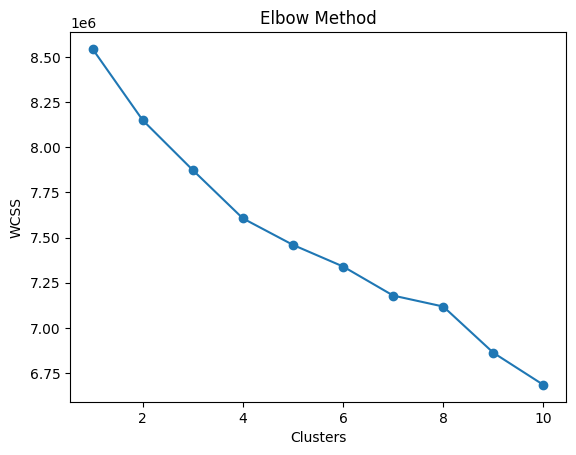

In [21]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

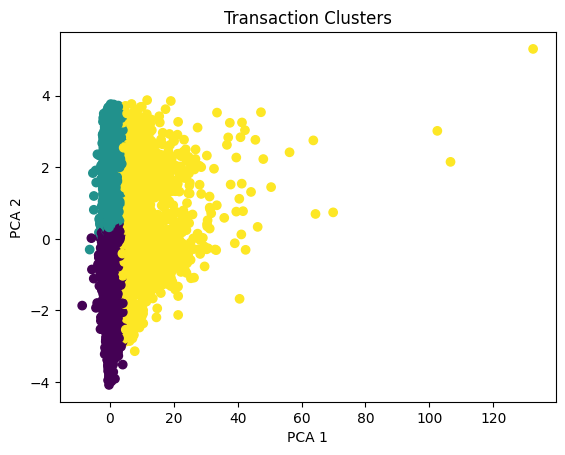

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Transaction Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

WCSS(Within Cluster Sum of Squares(not normalized)): 7873491.858168931
[1.         0.78797173 0.63942241 0.49560589 0.41676075 0.3524141
 0.26588604 0.23325052 0.09562831 0.        ]


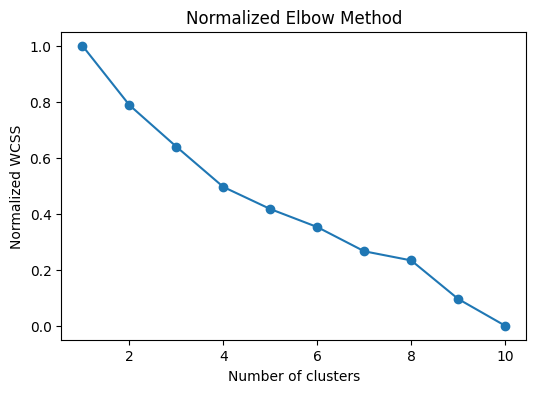

In [26]:
print('WCSS(Within Cluster Sum of Squares(not normalized)):', kmeans.inertia_)

wcss=[]

for k in range(1,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

wcss_norm=(wcss-np.min(wcss))/(np.max(wcss)-np.min(wcss))
print(wcss_norm)

k_values=range(1, 11)

plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss_norm, marker='o')
plt.title('Normalized Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Normalized WCSS')
plt.show()

In [29]:
idx = np.random.choice(len(X_scaled), 10000, replace=False)

X_sample = X_scaled[idx]
clusters_sample = clusters[idx]

sil_score = silhouette_score(X_sample, clusters_sample)
print("Silhouette Score:", sil_score)

db = davies_bouldin_score(X_sample, clusters_sample)
print("Davies-Bouldin Score:", db)

Silhouette Score: 0.06691894496734425
Davies-Bouldin Score: 3.0737837878871983


Average Silhouette Score: 0.11756377277007522


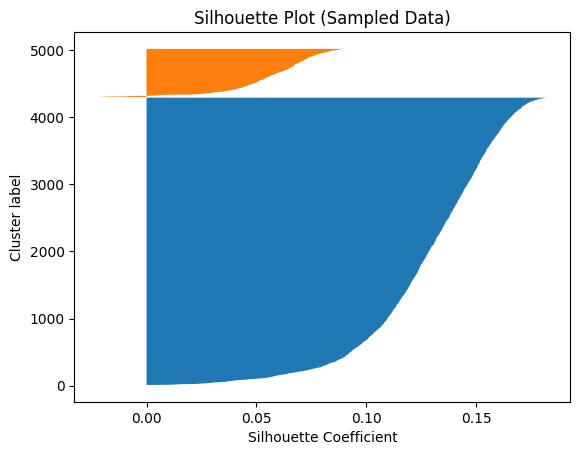

In [31]:
sample_size = 5000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)

X_sample = X_scaled[idx]

kmeans = KMeans(n_clusters=2, random_state=42)
labels_sample = kmeans.fit_predict(X_sample)

sil_avg = silhouette_score(X_sample, labels_sample)
print("Average Silhouette Score:", sil_avg)

sample_silhouette_values = silhouette_samples(X_sample, labels_sample)
plt.figure()
y_lower = 10

for i in range(2):
    ith_cluster_silhouette_values = sample_silhouette_values[labels_sample == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values
    )

    y_lower = y_upper + 10

plt.title('Silhouette Plot (Sampled Data)')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster label')
plt.show()